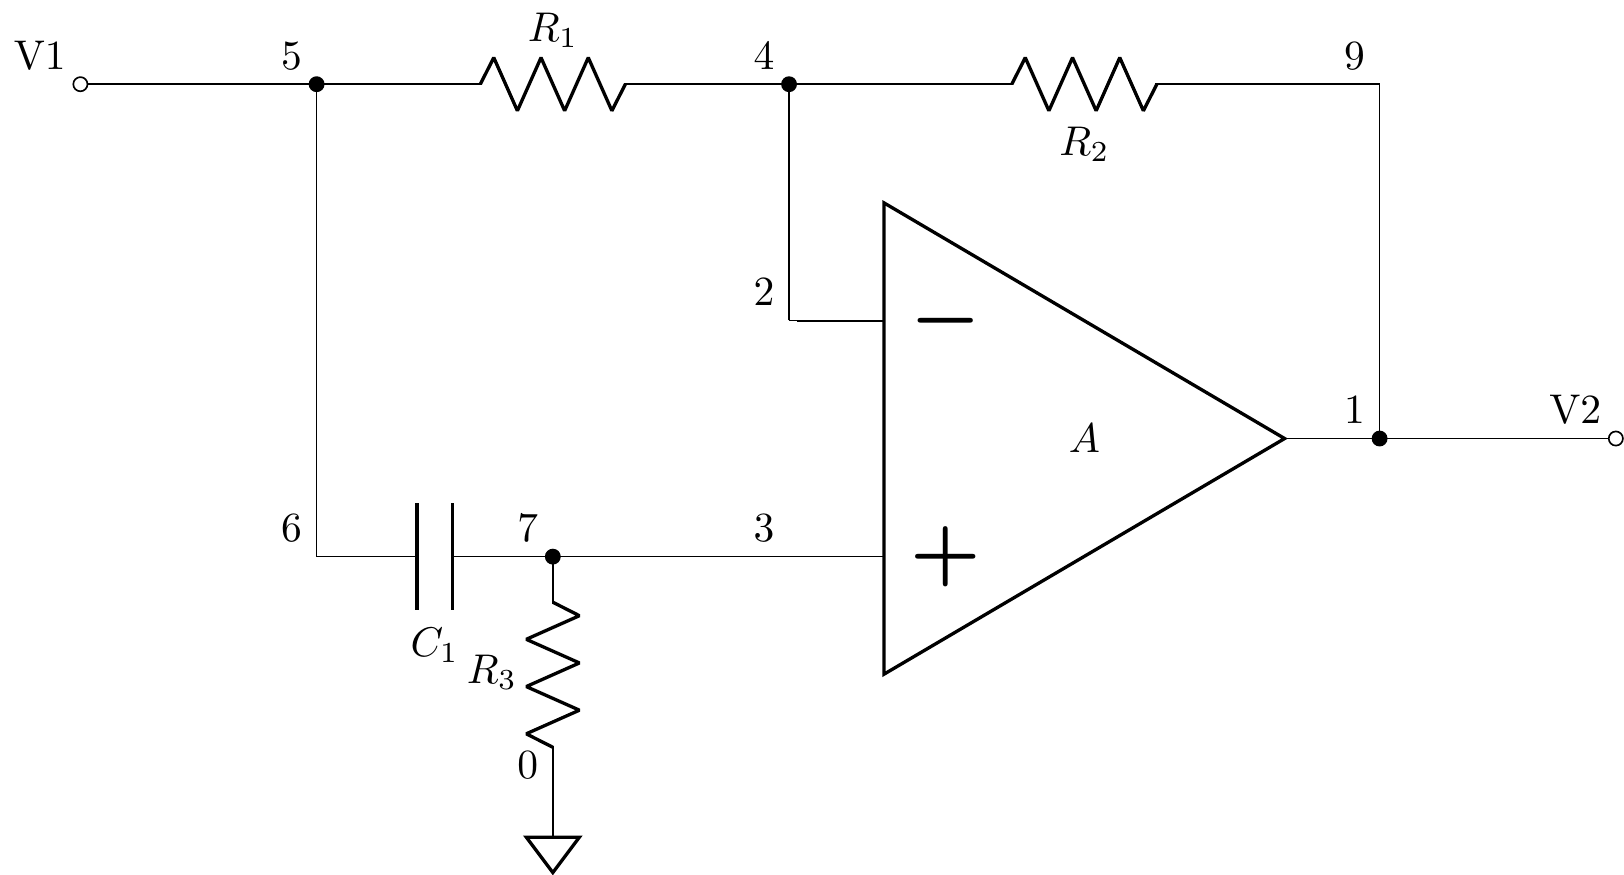

In [1]:
from lcapy import Circuit

c = Circuit("""
E 1 0 opamp 3 2 A; right, flipud
W1 2 4; up
R1 4 5 R1; left
R2 4 9 R2; right
W2 5 6; down
C1 6 7 C1; right
R3 7 0 R3; down
W3 9 1; down
W4 1 V2; right
W5 5 V1; left
W6 3 7; left
; autoground=true, label_ids=false, draw_nodes=connections
""")

c.draw(node_spacing = 2)

In [40]:
from sympy import simplify
H = c.transfer(5, 0, 9, 0)
#H = simplify(H.subs({'A': oo}))
print(simplify(H)) #Verifica

(A*(C1*R1*R3*s - R2)/(C1*R3*(A*R1 + R1 + R2)))/(s + 1/(C1*R3))


## Análisis nodal para obtener H(s)

### Ecuaciones nodales

$$
\begin{cases}
(V_1 - V_x)sC = \dfrac{V_x}{R_3} \\
\\
\dfrac{V_1 - V_x}{R_1} = \dfrac{V_x - V_2}{R_2}
\end{cases}
\quad
\begin{aligned}
&\Rightarrow V_x = \dfrac{V_1 sC R_3}{1 + sC R_3} \\
\\
&\Rightarrow \dfrac{V_1}{R_1} + \dfrac{V_2}{R_2} = V_x \left( \dfrac{R_1 + R_2}{R_1 R_2} \right)
\end{aligned}
$$
*Nota: $V_x$ es la tension en la pata inversora/no inversora del operacional*

**Sustituyendo $V_x$**

$$\frac{V_1}{R_1} + \frac{V_2}{R_2} =\frac{V_1 sC R_3}{1 + sC R_3} \cdot \frac{R_1 + R_2}{R_1 R_2}$$

**Despeje de $V_2$**

$$\frac{V_2}{R_2} =V_1 \left[\frac{sC R_3 (R_1 + R_2)}{R_1 R_2 (1 + sC R_3)} - \frac{1}{R_1}\right] \Rightarrow V_2 =V_1 \left[\frac{sC R_3 (R_1 + R_2)}{R_1 (1 + sC R_3)} - \frac{R_2}{R_1}\right]$$


**Desarrollo algebraico**

$$V_2 =V_1 \left[\frac{sC R_3 (R_1 + R_2) - R_2 (1 + sC R_3)}{R_1 (1 + sC R_3)}\right]=V_1 \cdot\frac{sC R_3 R_1 + sC R_3 R_2 - R_2 - sC R_3 R_2}{R_1 (1 + sC R_3)}=V_1 \cdot\frac{sC R_3 R_1 - R_2}{R_1 (1 + sC R_3)}$$

### **Función de transferencia**

$$\frac{V_2}{V_1} =\frac{sC R_3 R_1 - R_2}{R_1 (1 + sC R_3)} =\frac{sC R_3 R_1 - R_2}{sC R_3 R_1 + R_1}$$
$$\boxed{H(s) =\frac{s - \frac{R_2}{R_1 R_3 C}}{s + \frac{1}{R_3 C}}}$$

---

# Normalizacion

#### **Normalización en Impedancia**

Se define una constante de impedancia de referencia:

$$
Z_0 = 1 \, \Omega
$$

Las resistencias y capacitores se expresan en función de $Z_0$:

- $R' = \frac{R_3}{Z_0} \Rightarrow \quad $ Porque es comun al termino lineal en el numere
- $C'= C \cdot Z_0$
- $R_2 = R_1$ Por ser un **PASA TODO** la transferencia queda: $$ \boxed{H(s) = \frac{s - 1}{s + 1}}$$
  

####  **Normalización en Frecuencia Angular**

Se define una frecuencia angular de referencia:

$$
\omega_0 = \frac{1}{R_3 C}
$$

Se normaliza la variable $ S $ como:

$$
s = \frac{S}{\omega_0}
$$

Entonces, la función de transferencia:

$$
H(s) = \frac{S - \frac{R_2}{R_1} \cdot \frac{1}{R_3 C}}{S + \frac{1}{R_3 C}}
$$

Como es un pasa todo: $$H(s) = \frac{s\cdot\omega_0 - \omega_0}{s\cdot\omega_0 + \omega_0} = \frac{\omega_0\cdot(s-1)}{\omega_0\cdot(s+1)} \quad \Rightarrow \quad \boxed{H(s) = \frac{s - 1}{s + 1}} $$


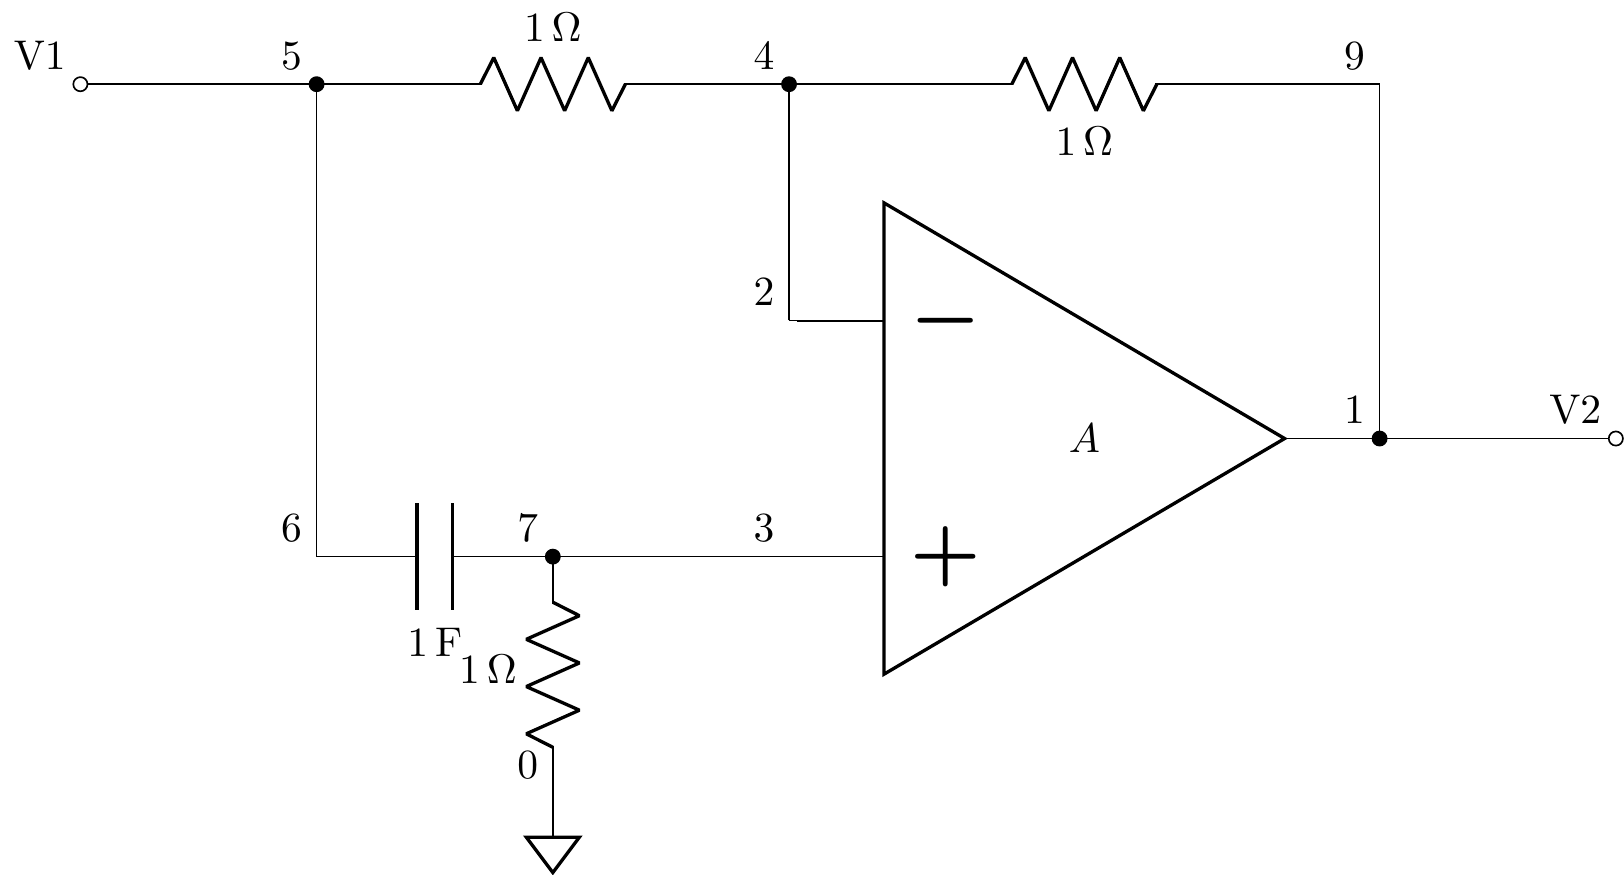

In [41]:
# Normalizo el circuito en python:
R1 = 1
R2 = 1
R3 = 1
C1 = 1
c_norm = Circuit(f"""
E 1 0 opamp 3 2 A; right, flipud
W1 2 4; up
R1 4 5 {R1}; left
R2 4 9 {R2}; right
W2 5 6; down
C1 6 7 {C1}; right
R3 7 0 {R3}; down
W3 9 1; down
W4 1 V2; right
W5 5 V1; left
W6 3 7; left
; autoground=true, label_ids=false, draw_nodes=connections
""")

c_norm.draw(node_spacing = 2)


In [45]:
H = c_norm.transfer(5, 0, 9, 0)
print(simplify(H_ideal)) #Recordar: A/(A+1) = 1

(A*(s - 1)/(A + 2))/(s + 1)


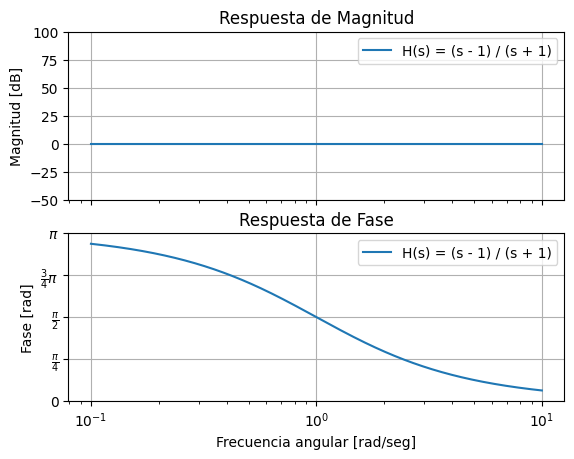

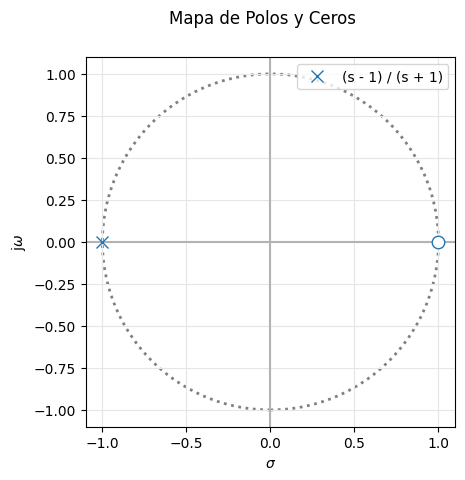

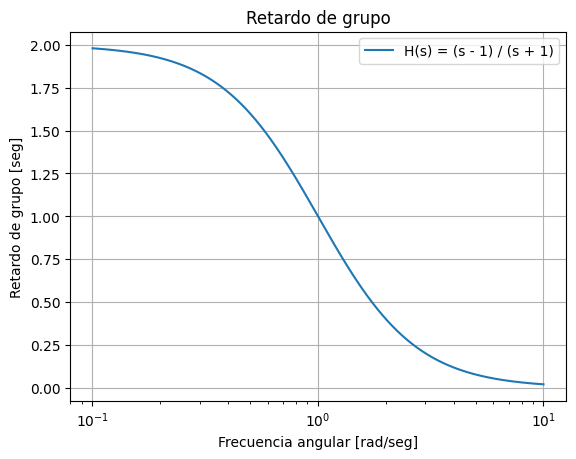

In [3]:
import pytc2
from scipy.signal import TransferFunction
import matplotlib.pyplot as plt
import numpy as np

from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot
#Transferencia normalizada en impedancia

# Parámetros de la transferencia normalizada
R2_R1 = 1
num = [1, -R2_R1]
den = [1, 1]

# Crear función de transferencia
my_tf = TransferFunction(num, den)

# Graficar
bodePlot(my_tf, fig_id=1, filter_description = f'H(s) = (s - {R2_R1}) / (s + 1)' )
pzmap(my_tf, fig_id=2, filter_description = f'(s - {R2_R1}) / (s + 1)') 
GroupDelay(my_tf, fig_id=3, filter_description = f'H(s) = (s - {R2_R1}) / (s + 1)')

plt.show()

**El  MF-103 utiliza celdas de este estilo**

# Simulacion Circuital en LTspice
**Desnormalizo**

- $R_1 = 1 \text{K}\Omega$
- $R_2 = 1 \text{K}\Omega$
- $R_3 = 1 \text{K}\Omega$
- $C = 1 \mu \text{F}$

$$ \omega_0 = \frac{1}{R_3 C} \Rightarrow \quad \omega_0 = 1000 \text(r/s) \Rightarrow \quad f_o= \frac{\omega_0}{2\pi}$$
$$ f_O \approx 159 \text{Hz}$$

**Esto quiere decir que a 159Hz la fase es 90º**

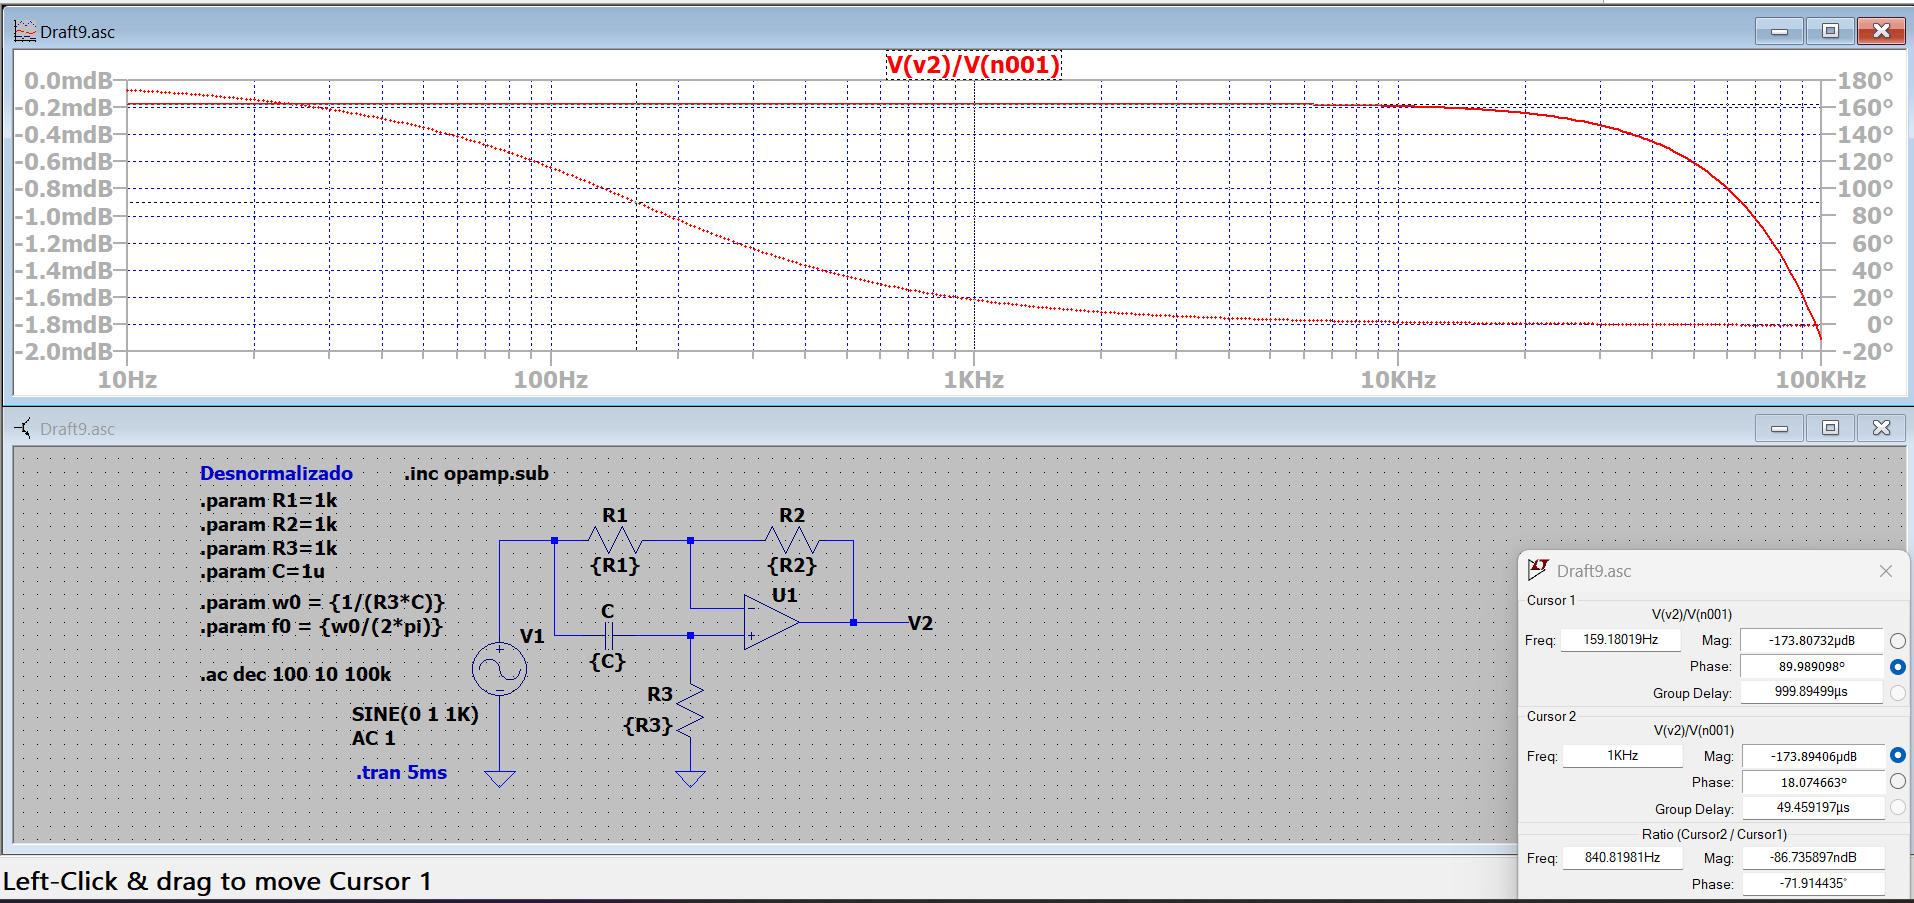

In [49]:
from IPython.display import Image
Image("C:/Users/adria/OneDrive/Escritorio/jupy/FOTOS/FOTO_S0_ALLPASS.png")

# Analisis de similitudes y diferencias entre circuitos

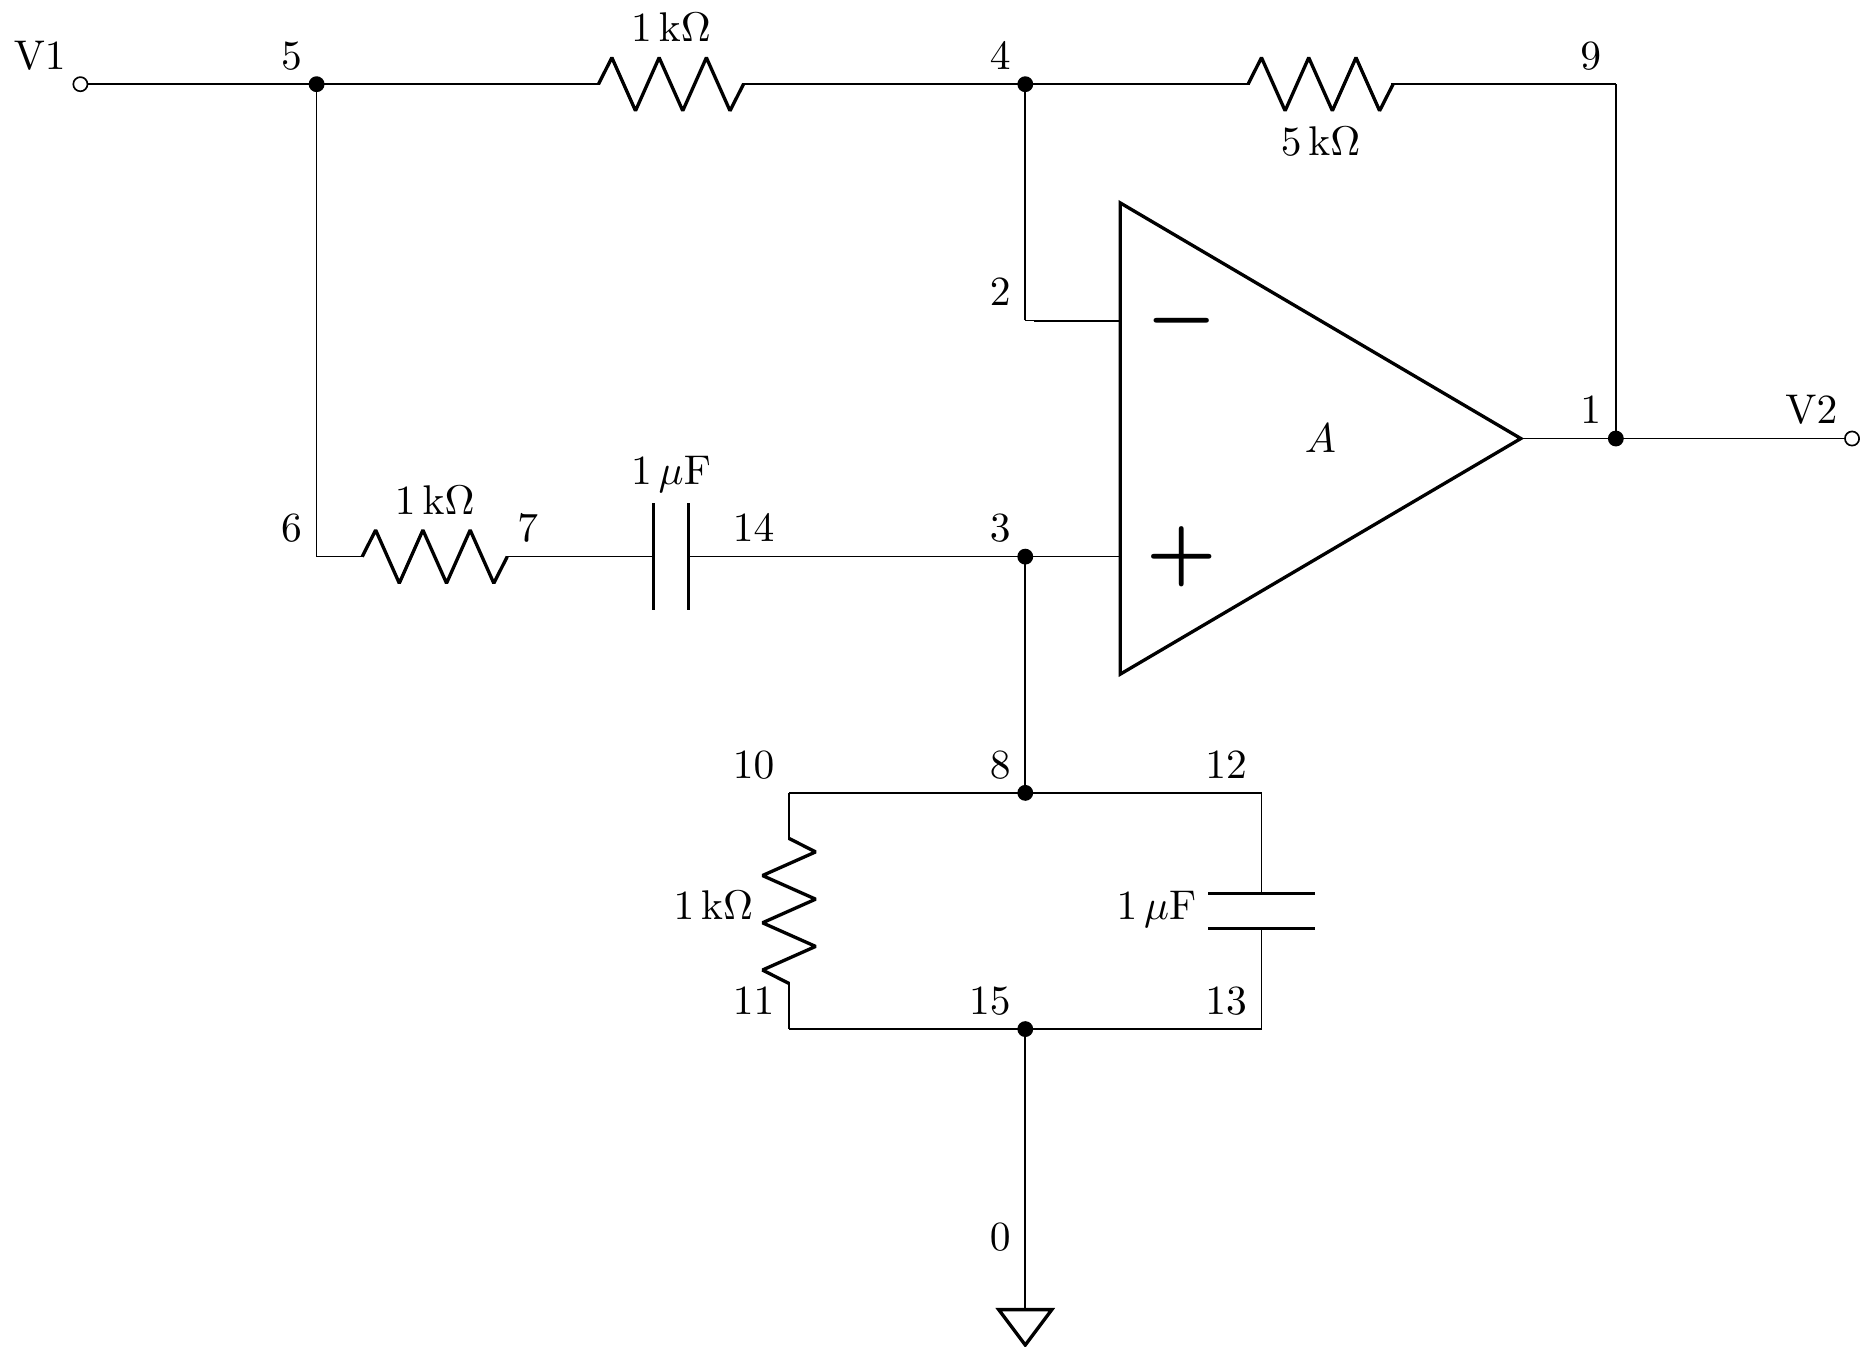

In [31]:
k = 5
R = 1e3
R1 = R
C = 1e-6
C1 = C
R_B = 1e3
R_A = k*R_B
c7 = Circuit(f"""
E 1 0 opamp 3 2 A; right, flipud
W1 2 4; up
R_A 4 5 {R_A}; left
R_B 4 9 {R_B}; right
W2 5 6; down
W3 3 14; left
C 14 7 {C}; left
R 7 6 {R}; left
W4 3 8; down
W5 8 10; left
W6 8 12; right
R1 10 11 {R1}; down
C1 12 13 {C1}; down
W7 11 15; right
W8 13 15; left
W9 9 1; down
W10 5 V1; left
W11 1 V2; right
W12 15 0; down 
; autoground=true, label_ids=false, draw_nodes=connections
""")

c7.draw(node_spacing = 2)

### Ecuaciones nodales

$$
\left\{
\begin{array}{l}
\dfrac{V_1 - V_x}{R_A} = \dfrac{V_x - V_2}{R_B}
\\[12pt]
\dfrac{V_1 - V_x}{R + \frac{1}{sC}} = V_x\left(\dfrac{1}{R} + sC\right)
\end{array}
\right.
\qquad
\begin{array}{l}
\Rightarrow V_x = \dfrac{V_1R_B + V_2R_A}{R_A + R_B}
\\[12pt]
\Rightarrow V_x = \dfrac{V_1}{3 + \dfrac{1}{RsC} + RsC}
\end{array}
$$
*Nota: $V_x$ es la tensión en la entrada inversora y no inversora del operacional*
### Igualando ambas expresiones de $V_x$

$$\frac{V_1}{3+\frac{1}{RsC}+RsC}=\frac{V_1R_B+V_2R_A}{R_A+R_B}$$

$$V_1(R_A+R_B)=(V_1R_B+V_2R_A)\left(3+\frac{1}{RsC}+RsC\right)$$

$$V_1(R_A+R_B)=V_1R_B\left(3+\frac{1}{RsC}+RsC\right)+V_2R_A\left(3+\frac{1}{RsC}+RsC\right)$$

$$V_1(R_A+R_B)=3V_1R_B+\frac{V_1R_B}{RsC}+V_1R_BRsC+3V_2R_A+\frac{V_2R_A}{RsC}+V_2R_ARsC$$

$$V_1\left(R_A+R_B-3R_B-\frac{R_B}{RsC}-R_BRsC\right)=V_2\left(3R_A+\frac{R_A}{RsC}+R_ARsC\right)$$

$$V_1\left(R_A-2R_B-\frac{R_B}{RsC}-R_BRsC\right)=V_2\left(3R_A+\frac{R_A}{RsC}+R_ARsC\right)$$

$$\frac{V_2}{V_1}=\frac{R_A-2R_B-\frac{R_B}{RsC}-R_BRsC}{3R_A+\frac{R_A}{RsC}+R_ARsC}$$

$$\frac{V_2}{V_1}=\frac{R_ARsC-2R_BRsC-R_B-R_B(RsC)^2}{3R_ARsC+R_A+R_A(RsC)^2}$$

$$\frac{V_2}{V_1}=\frac{-s^2R^2C^2R_B+sRC(R_A-2R_B)-R_B}{s^2R^2C^2R_A+3sRCR_A+R_A}$$

$$\frac{V_2}{V_1}=\frac{-s^2\frac{R_B}{R_A}+s\frac{R_A-2R_B}{RCR_A}-\frac{R_B}{R_A}\frac{1}{R^2C^2}}{s^2+s\frac{3}{RC}+\frac{1}{R^2C^2}}$$

**Definino:**

$$k=\frac{R_B}{R_A} = 5 \quad \land \quad \omega_0^2=\frac{1}{R^2C^2} \quad \Rightarrow \quad \omega = \frac{1}{RC}$$

$$H(s)=\frac{V_2}{V_1}=\frac{-ks^2+s\left(\frac{R_A-2R_B}{RCR_A}\right)-k\omega_0^2}{s^2+s\frac{3}{RC}+\omega_0^2} \quad \Rightarrow \quad \boxed{H(s)=(-k) \cdot \frac{s^2 - s\cdot\frac{3}{RC} + \omega_0^2}{s^2 + s\cdot\frac{3}{RC} + \omega_0^2}}$$

**Forma generica de un filtro PASA TODO DE SEGUNDO ORDEN:**
$$H(s) = \frac{s^2 - s\cdot\frac{\omega_z}{Q_z} + \omega_z^2}{s^2 + s\cdot\frac{\omega_p}{Q_p} + \omega_p^2}$$

Igualo los terminos:

$$
\begin{cases}
\omega_z^2 = \omega_p^2 = \omega_0 = \dfrac{1}{R^2C^2} \quad \Rightarrow \quad \omega_0 = \frac{1}{RC}
\\[10pt]
\dfrac{\omega_z}{Q_z}=\frac{\omega_p}{Q_p}= Q =\dfrac{3}{RC} = 3\cdot\omega_0 \quad \Rightarrow \quad Q = \frac{1}{3}
\end{cases}
$$

Datos:
$$\frac{R_A}{R_B} = 5 = K \quad , \quad R = 1k\ohm \quad , \quad C = 1\mu F \quad \Rightarrow \quad \omega_0 = 1000 \frac{r}{s}$$

**Entonces:**

$$\boxed{H(s)=(-5) \cdot \frac{s^2 - 3\cdot\omega_0\cdot s + \omega_0^2}{s^2 + 3\cdot\omega_0\cdot s + \omega_0^2} \quad \Rightarrow \quad H(s)=(-5) \cdot \frac{s^2 - 3000\cdot s + 1000000}{s^2 + 3000\cdot s + 1000000}}$$

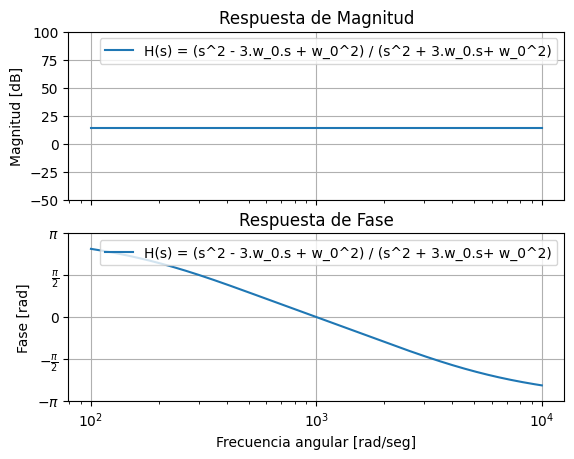

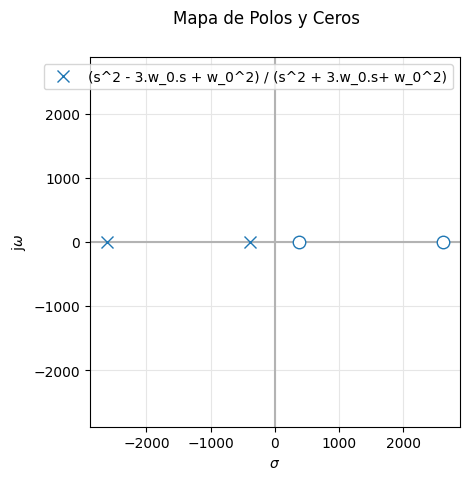

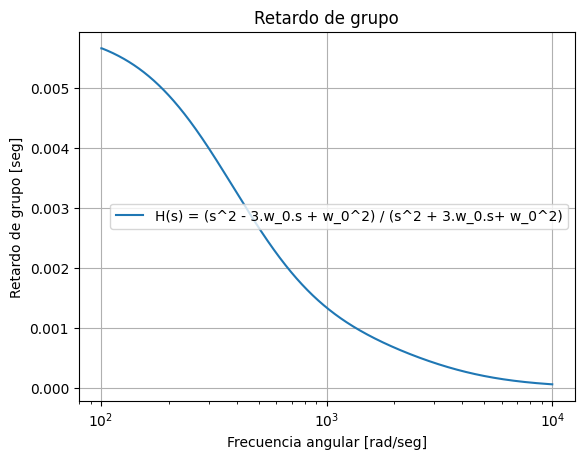

In [4]:
# Parámetros de la transferencia normalizada
k = 5
R = 1e3
R1 = R
C = 1e-6
C1 = C
R_B = 1e3
R_A = k*R_B
w_0=1 / (R*C)
num = [-k, 3*w_0*k, -k*(w_0**2)] 
den = [1, 3*w_0, w_0**2]

# Crear función de transferencia
my_tf = TransferFunction(num, den)

# Graficar
bodePlot(my_tf, fig_id=1, filter_description = f'H(s) = (s^2 - 3.w_0.s + w_0^2) / (s^2 + 3.w_0.s+ w_0^2)' )
pzmap(my_tf, fig_id=2, filter_description = f'(s^2 - 3.w_0.s + w_0^2) / (s^2 + 3.w_0.s+ w_0^2)') 
GroupDelay(my_tf, fig_id=3, filter_description = f'H(s) = (s^2 - 3.w_0.s + w_0^2) / (s^2 + 3.w_0.s+ w_0^2)')

plt.show()

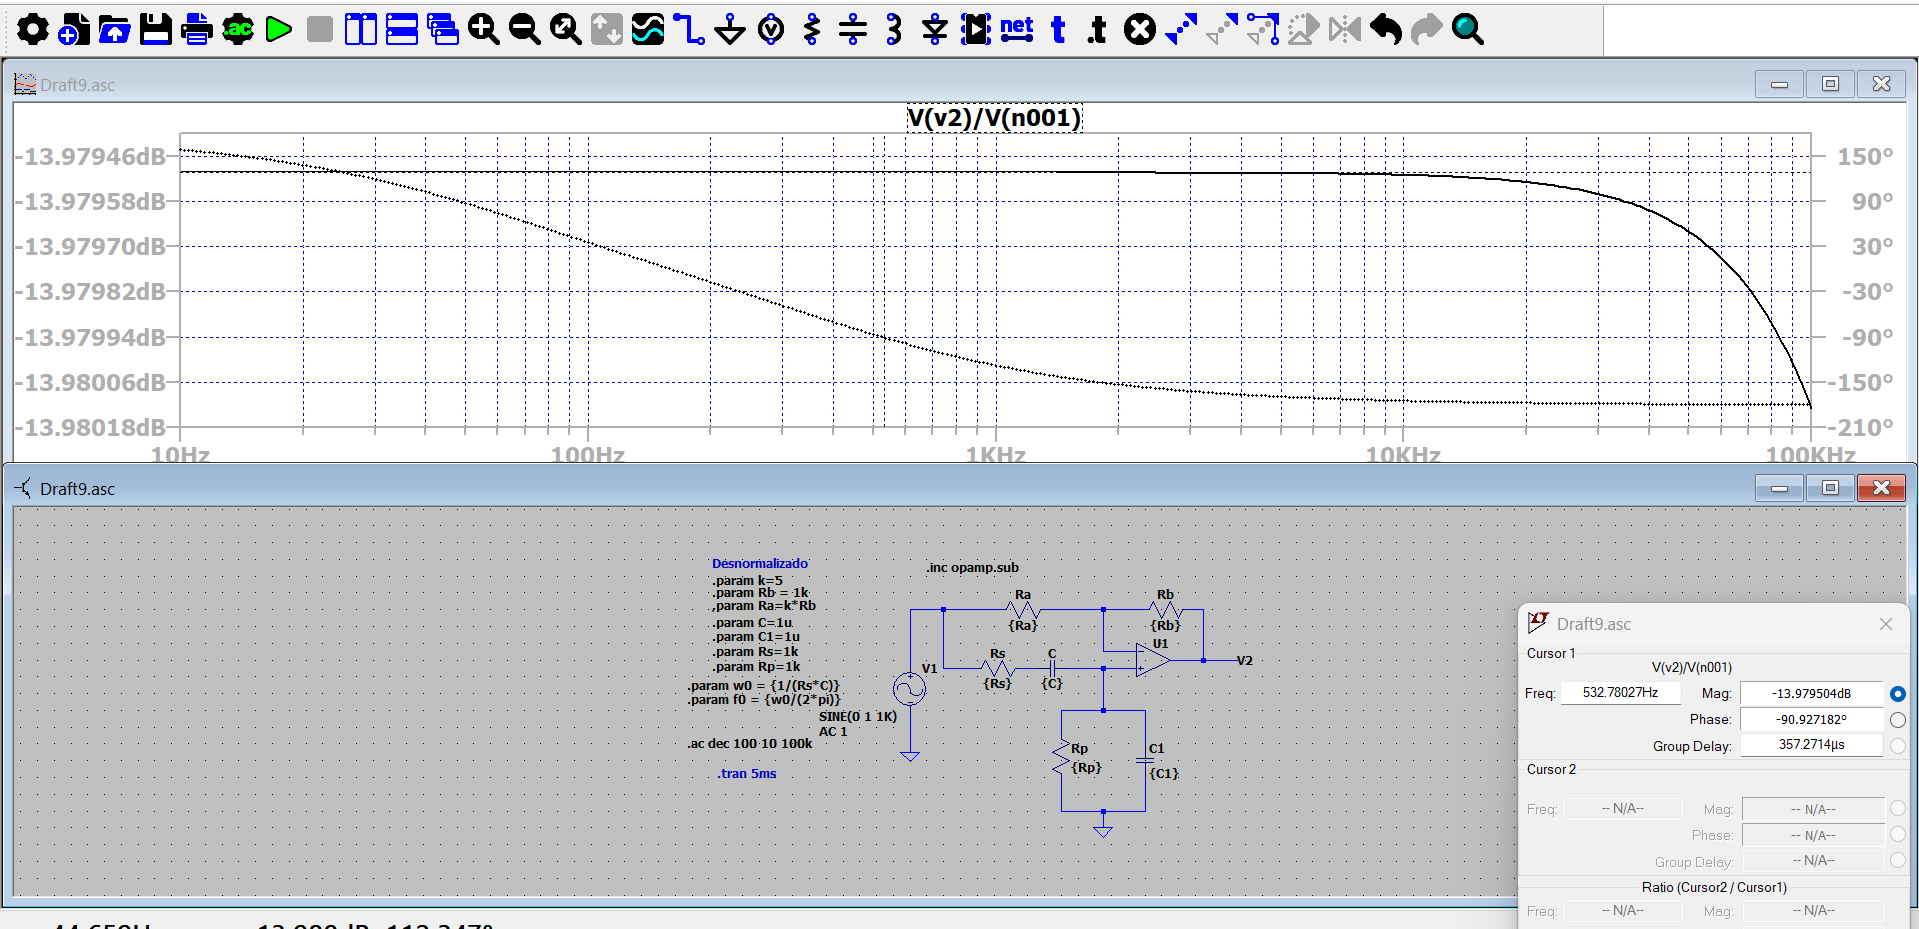

In [5]:
from IPython.display import Image
Image("C:/Users/adria/OneDrive/Escritorio/jupy/FOTOS/FOTO_TS0_AP_2.png")

### Verificacines
Paso a dominio frecuencial: $s=j\omega$

queda:

$$H(j\omega)=(-5)\cdot\frac{(j\omega)^2-3\omega_0(j\omega)+\omega_0^2}{(j\omega)^2+3\omega_0(j\omega)+\omega_0^2} \quad \Rightarrow \quad (j\omega)^2=-\omega^2 \quad \Rightarrow \quad H(j\omega)=(-5)\cdot\frac{\omega_0^2-\omega^2-j3\omega_0\omega}{\omega_0^2-\omega^2+j3\omega_0\omega}$$

**Análisis de magnitud**

El factor:

$$(-5) \quad \Rightarrow \quad |H|=5 \quad \Rightarrow \quad  20\log(5)=13.98\ dB$$
Esto coincide con la simulación de LTspice.

**Analisis de la fase**

Fase de un número complejo

$$z=a+jb \quad \Rightarrow \quad\angle z=\tan^{-1}\left(\frac{b}{a}\right)$$

*Fase del numerador*

$$N(\omega)=\omega_0^2-\omega^2-j3\omega_0\omega$$

$$a=\omega_0^2-\omega^2 \quad \land \quad b=-3\omega_0\omega \quad \Rightarrow \quad \angle N=\tan^{-1}\left(\frac{-3\omega_0\omega}{\omega_0^2-\omega^2}\right)$$

*Fase del denominador*

$$D(\omega)=\omega_0^2-\omega^2+j3\omega_0\omega$$
$$a=\omega_0^2-\omega^2\quad \land \quad b=3\omega_0\omega\quad \Rightarrow \quad\angle D=\tan^{-1}\left(\frac{3\omega_0\omega}{\omega_0^2-\omega^2}\right)$$

*Fase total*

$$\angle\left(\frac{N}{D}\right)=\angle N-\angle D$$

Además: $(-5)=5(-1)$ El factor $5$ no aporta fase, el factor $-1$ aporta $180^\circ$

Entonces: $\phi(\omega)=180^\circ+\angle N-\angle D \quad \Rightarrow \quad \angle N=-\angle D$

Se obtiene: $\phi(\omega)=180^\circ-2\angle D$

Finalmente:

$$\boxed{\phi(\omega)=180^\circ-2\tan^{-1}\left(\frac{3\omega_0\omega}{\omega_0^2-\omega^2}\right)}$$

**Frecuencia para fase de $-90^\circ$**

Se impone:

$$\phi(\omega)=-90^\circ$$

Entonces:

$$180^\circ-2\theta=-90^\circ \quad \Rightarrow \quad \theta=135^\circ \quad \Rightarrow \quad \tan(135^\circ)=-1$$


se obtiene:

$$\frac{3\omega_0\omega}{\omega_0^2-\omega^2}=-1 \quad \Rightarrow \quad \omega^2-3\omega_0\omega-\omega_0^2=0$$


Reemplazando:

$$\omega_0=1000\ rad/s$$

$$\omega^2-3000\omega-10^6=0$$

Resolviendo:

$$\omega\approx 3302.8\ rad/s \quad \Rightarrow \quad f=\frac{\omega}{2\pi}  \quad \Rightarrow \quad f\approx 525.7\ Hz$$

Valor muy cercano al observado en LTspice: $f\approx 532.8\ Hz$


La diferencia es mínima y se debe a la resolución gráfica del cursor.

Por lo tanto:

- La magnitud constante de **13.98 dB** coincide con el factor de ganancia:

$$K=5$$

- La frecuencia de fase de $-90^\circ$ también coincide con el análisis teórico.

---

### Conclusión final
Debido a que el filtro presenta un factor de calidad bajo ($Q=\frac{1}{3}$), la transición de fase resulta más gradual que en un pasa-todo de primer orden. Por esta razón, la frecuencia para la cual la fase alcanza $-90^\circ$ no coincide con $\omega_0$, sino que se desplaza hacia una frecuencia mayor ($\omega = 3.3\omega_0$, sale de la cuadratica).